# Load the Disaster Tweets
Let's have a look at the train and test dataset.

They contain:
- id
- keyword: A keyword from that tweet (although this may be blank!)
- location: The location the tweet was sent from (may also be blank)
- text: The text of a tweet
- target: 1 if the tweet is a real disaster or 0 if not

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Step 2 Recipe: Fix the random seed for reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# Check hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Using device: cuda


In [2]:
df_train = pd.read_csv("/kaggle/input/nlp-getting-started/train.csv")
df_test = pd.read_csv("/kaggle/input/nlp-getting-started/test.csv")

print('Training Set Shape = {}'.format(df_train.shape))
print('Training Set Memory Usage = {:.2f} MB'.format(df_train.memory_usage().sum() / 1024**2))
print('Test Set Shape = {}'.format(df_test.shape))
print('Test Set Memory Usage = {:.2f} MB'.format(df_test.memory_usage().sum() / 1024**2))

Training Set Shape = (7613, 5)
Training Set Memory Usage = 0.29 MB
Test Set Shape = (3263, 4)
Test Set Memory Usage = 0.10 MB


In [3]:
df_train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
df_test.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [5]:
train_df = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')

# Class Distribution
print("--- Class Distribution ---")
print(train_df['target'].value_counts(normalize=True))

--- Class Distribution ---
0    0.57034
1    0.42966
Name: target, dtype: float64


In [6]:
# Likelihoods
print("P(Disaster | Has Keyword):", train_df[train_df['keyword'].notna()]['target'].mean())
print("P(Disaster | Has Location):", train_df[train_df['location'].notna()]['target'].mean())
print("P(Disaster | Has Both):", train_df[train_df['keyword'].notna() & train_df['location'].notna()]['target'].mean())

P(Disaster | Has Keyword): 0.4275688559322034
P(Disaster | Has Location): 0.4322834645669291
P(Disaster | Has Both): 0.4322834645669291


In [7]:
has_k = train_df['keyword'].notna()
has_l = train_df['location'].notna()

print("P(Disaster | Has Keyword Only):", train_df[has_k & ~has_l]['target'].mean())
print("P(Disaster | Has Location Only):", train_df[~has_k & has_l]['target'].mean())
print("P(Disaster | Has Both):", train_df[has_k & has_l]['target'].mean())
print("P(Disaster | Has Neither):", train_df[~has_k & ~has_l]['target'].mean())

P(Disaster | Has Keyword Only): 0.4178802588996764
P(Disaster | Has Location Only): nan
P(Disaster | Has Both): 0.4322834645669291
P(Disaster | Has Neither): 0.6885245901639344


In [8]:
print(pd.crosstab(
    [train_df['keyword'].notna(), train_df['location'].notna()], 
    train_df['target'], 
    margins=True, 
    rownames=['Has Keyword', 'Has Location']
))

target                       0     1   All
Has Keyword Has Location                  
False       False           19    42    61
True        False         1439  1033  2472
            True          2884  2196  5080
All                       4342  3271  7613


In [ ]:
# visualize

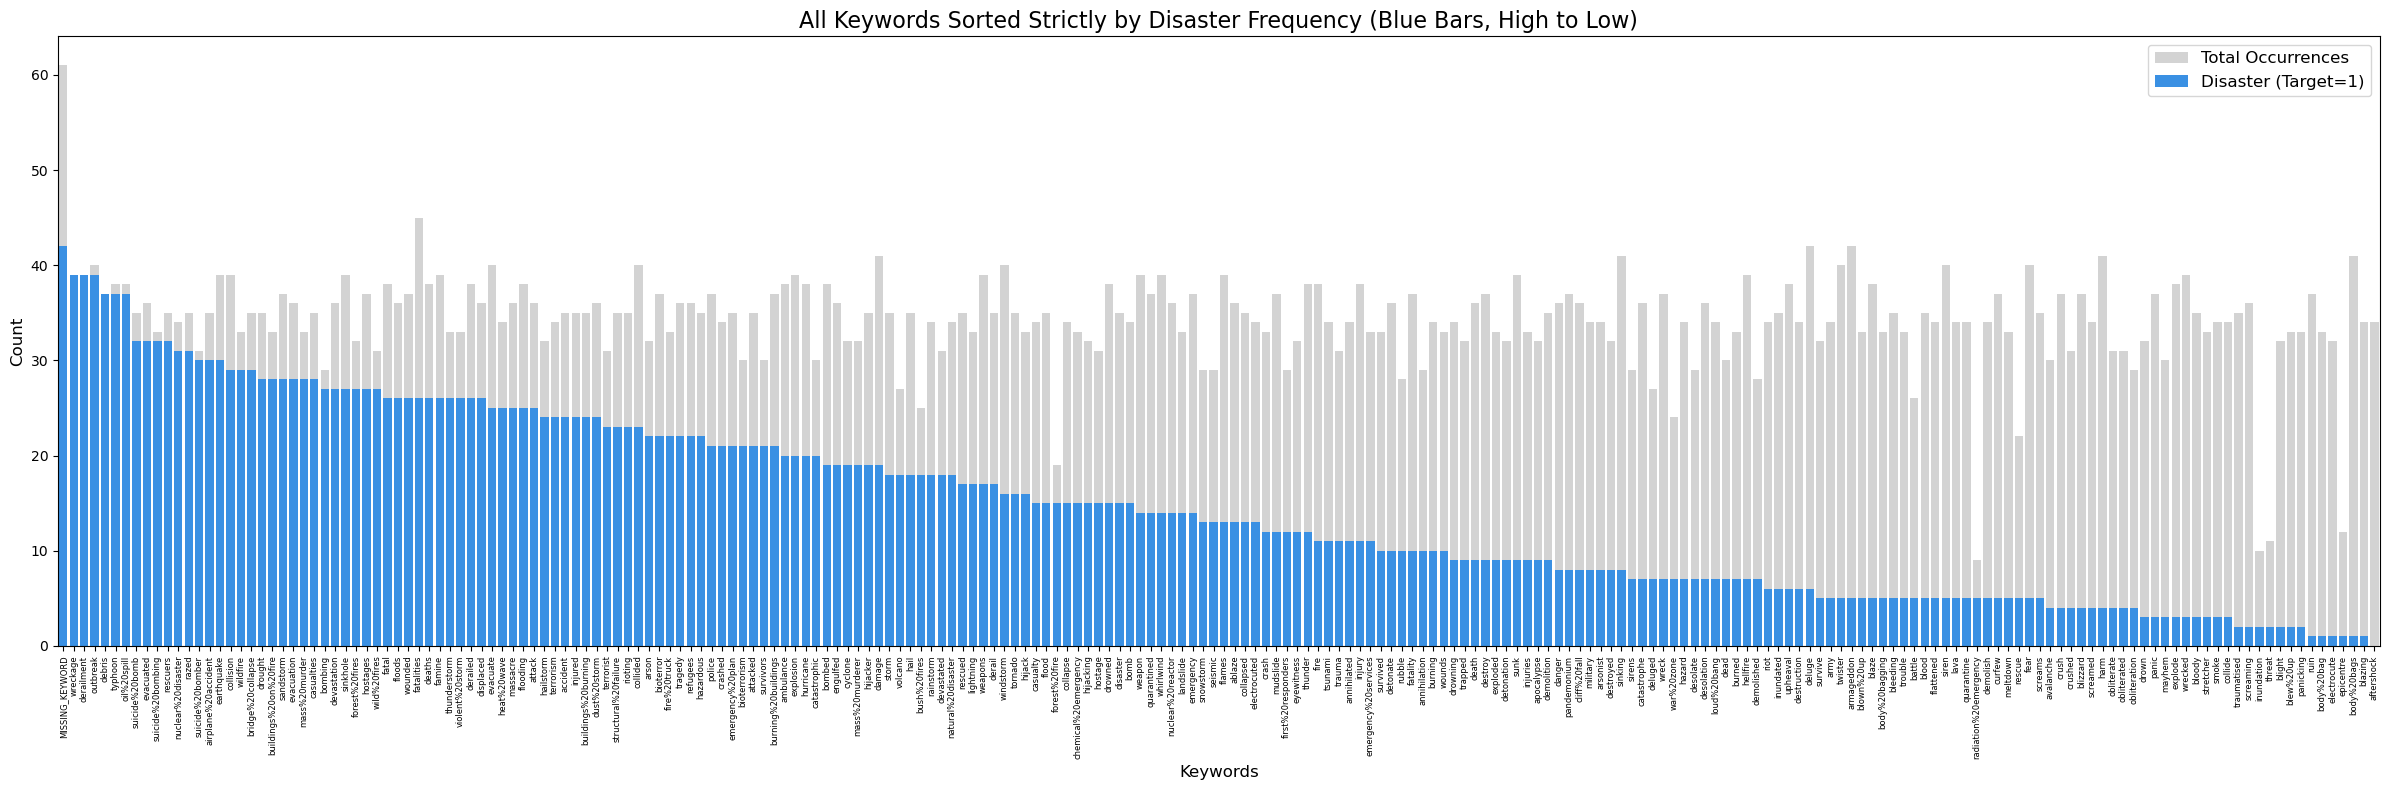

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fill missing keywords with a placeholder string
df_filled = train_df.copy()
df_filled['keyword'] = df_filled['keyword'].fillna('MISSING_KEYWORD')

# 2. Cross-tabulate counts per keyword based on the target
counts = pd.crosstab(df_filled['keyword'], df_filled['target'])
counts['Total'] = counts[0] + counts[1]

# 3. Sort strictly by the disaster count (column 1 / blue bar) from high to low
counts_sorted_by_blue = counts.sort_values(by=1, ascending=False)

# 4. Plotting
plt.figure(figsize=(24, 8))

# Total count in Gray (remains the backdrop)
sns.barplot(x=counts_sorted_by_blue.index, y=counts_sorted_by_blue['Total'], color='lightgray', label='Total Occurrences')
# Disaster count in Blue (this will now form a perfect descending step-down curve)
sns.barplot(x=counts_sorted_by_blue.index, y=counts_sorted_by_blue[1], color='dodgerblue', label='Disaster (Target=1)')

# Clean up layout and rotation
plt.xticks(rotation=90, fontsize=6)
plt.title("All Keywords Sorted Strictly by Disaster Frequency (Blue Bars, High to Low)", fontsize=16)
plt.xlabel("Keywords", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

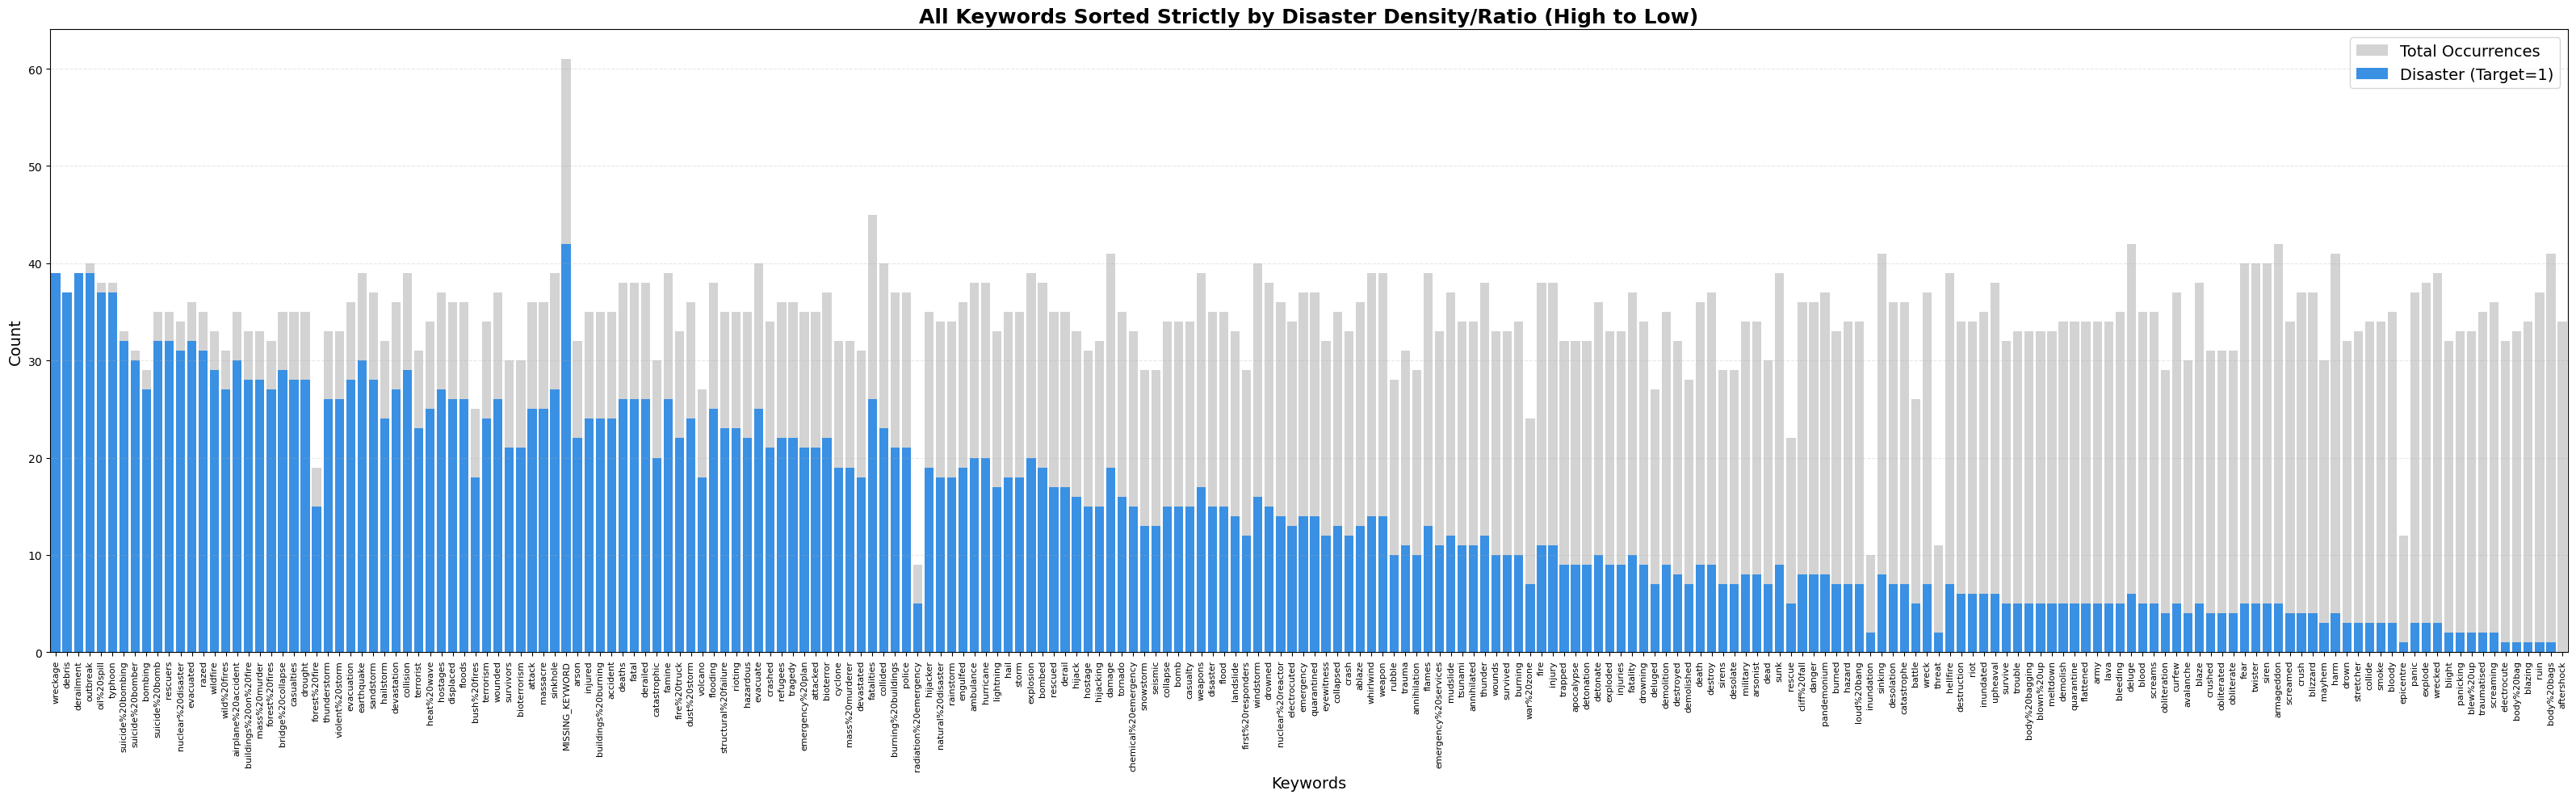

In [10]:
# visualize

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Fill missing keywords with a placeholder string
df_filled = train_df.copy()
df_filled['keyword'] = df_filled['keyword'].fillna('MISSING_KEYWORD')

# 2. Cross-tabulate counts per keyword based on the target
counts = pd.crosstab(df_filled['keyword'], df_filled['target'])
counts['Total'] = counts[0] + counts[1]

# 3. Calculate pure density ratio
counts['Density'] = counts[1] / counts['Total']

# 4. Sort strictly by Density from high to low
counts_sorted_by_density = counts.sort_values(by='Density', ascending=False)

# 5. Create canvas
plt.figure(figsize=(32, 10))

# Total count in Gray
sns.barplot(x=counts_sorted_by_density.index, y=counts_sorted_by_density['Total'], color='lightgray', label='Total Occurrences')
# Disaster count in Blue
sns.barplot(x=counts_sorted_by_density.index, y=counts_sorted_by_density[1], color='dodgerblue', label='Disaster (Target=1)')

# Formatting text parameters
plt.xticks(rotation=90, fontsize=8, ha='center')
plt.title("All Keywords Sorted Strictly by Disaster Density/Ratio (High to Low)", fontsize=18, fontweight='bold')
plt.xlabel("Keywords", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.legend(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Simple tokenizer
import torch
from torch.utils.data import Dataset, DataLoader
import string
from collections import Counter

class CustomTokenizer:
    def __init__(self, max_vocab_size=10000, max_len=30):
        self.max_vocab_size = max_vocab_size
        self.max_len = max_len
        self.pad_token = "<PAD>"
        self.unk_token = "<UNK>"
        self.word2idx = {self.pad_token: 0, self.unk_token: 1}
        self.idx2word = {0: self.pad_token, 1: self.unk_token}
        
    def clean_text(self, text):
        text = str(text).lower().translate(str.maketrans('', '', string.punctuation))
        return text.split()

    def fit(self, texts):
        word_counts = Counter()
        for text in texts:
            word_counts.update(self.clean_text(text))
        for word, _ in word_counts.most_common(self.max_vocab_size - 2):
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, text):
        encoded = [self.word2idx.get(t, 1) for t in self.clean_text(text)]
        if len(encoded) > self.max_len:
            return encoded[:self.max_len]
        return encoded + [0] * (self.max_len - len(encoded))

# Initialize and fit it to your text column
tokenizer = CustomTokenizer(max_vocab_size=5000, max_len=25)
tokenizer.fit(train_df['text'])

class DisasterTweetsDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        
        # Pre-encode all texts to save compute during training loops
        self.encoded_sequences = [
            self.tokenizer.encode(text) for text in self.df['text']
        ]
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        # Fetch the pre-computed integer list
        tokens = self.encoded_sequences[idx]
        
        # Target classification label
        target = self.df.loc[idx, 'target']
        
        # Return as PyTorch tensors
        return {
            'input_ids': torch.tensor(tokens, dtype=torch.long),
            'label': torch.tensor(target, dtype=torch.float32)
        }

# Initialize the Dataset
dataset = DisasterTweetsDataset(train_df, tokenizer)

# Initialize the DataLoader (Batch Size B = 32)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Sanity Check shapes per the Recipe's "Verify shapes" phase
sample_batch = next(iter(dataloader))
print("Batch Input IDs Shape (B, T):", sample_batch['input_ids'].shape)
print("Batch Labels Shape (B,):     ", sample_batch['label'].shape)

Batch Input IDs Shape (B, T): torch.Size([32, 25])
Batch Labels Shape (B,):      torch.Size([32])


In [ ]:
# set proper initialization (~ 0.6)

In [12]:
import torch
import torch.nn as nn

class DisasterModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=32):
        super().__init__()
        # Maps token IDs to vectors: (B, T) -> (B, T, C)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        # Final classifier mapping to a single logit: (B, C) -> (B, 1)
        self.fc = nn.Linear(embed_dim, 1)
        
    def forward(self, x):
        x = self.embedding(x)      # Shape: (B, T, C)
        x = x.mean(dim=1)          # Shape: (B, C) - Average across the Time steps
        x = self.fc(x).squeeze(1)  # Shape: (B) - Remove the empty dimension
        return x

# 1. Initialize
model = DisasterModel(vocab_size=len(tokenizer.word2idx))
criterion = nn.BCEWithLogitsLoss()

# 2. Forward Pass on the sample batch
logits = model(sample_batch['input_ids'])
loss = criterion(logits, sample_batch['label'])

print(f"Expected: ~0.693")
print(f"Actual Initialization Loss: {loss.item():.4f}")

Expected: ~0.693
Actual Initialization Loss: 0.6734


In [ ]:
# Overfit on a single batch

In [13]:
import torch.optim as optim

# 1. Isolate exactly ONE batch
single_batch = next(iter(dataloader))
inputs = single_batch['input_ids']
labels = single_batch['label']

# 2. Setup Optimizer (High learning rate just to overfit instantly)
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("--- Overfitting a Single Batch ---")
for epoch in range(100):
    optimizer.zero_grad()
    
    # Forward
    logits = model(inputs)
    loss = criterion(logits, labels)
    
    # Backward
    loss.backward()
    optimizer.step()
    
    # Print progress
    if epoch % 20 == 0 or epoch == 99:
        preds = (torch.sigmoid(logits) >= 0.5).float()
        acc = (preds == labels).float().mean()
        print(f"Epoch {epoch:02d} | Loss: {loss.item():.4f} | Accuracy: {acc.item()*100:.0f}%")

--- Overfitting a Single Batch ---
Epoch 00 | Loss: 0.6799 | Accuracy: 59%
Epoch 20 | Loss: 0.4237 | Accuracy: 91%
Epoch 40 | Loss: 0.1393 | Accuracy: 100%
Epoch 60 | Loss: 0.0409 | Accuracy: 100%
Epoch 80 | Loss: 0.0176 | Accuracy: 100%
Epoch 99 | Loss: 0.0103 | Accuracy: 100%


In [ ]:
# Distilled Bert fine-tuning

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
import warnings
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. KILL KAGGLE JS ERRORS & SETUP DEVICE
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1" 
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[*] Compute Device: {device}")

# 2. FIX NAME ERROR: RELOAD DATA FROM SCRATCH
# Adjust this path if your Kaggle input directory is named differently
train_df = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')
train_split, val_split = train_test_split(train_df, test_size=0.2, random_state=42)

# 3. TOKENIZER & DATASET
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

class DisasterTweetsDatasetHF(Dataset):
    def __init__(self, df, tokenizer, max_len=32):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        text = str(self.df.loc[idx, 'text'])
        target = self.df.loc[idx, 'target']
        encoding = self.tokenizer.encode_plus(
            text, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(target, dtype=torch.float32)
        }

train_loader = DataLoader(DisasterTweetsDatasetHF(train_split, tokenizer), batch_size=32, shuffle=True)
val_loader = DataLoader(DisasterTweetsDatasetHF(val_split, tokenizer), batch_size=32, shuffle=False)

# 4. LOAD MODEL TO GPU
model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=1)
model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# 5. TRAINING LOOP
best_val_acc = 0
patience, patience_counter = 3, 0

print("\n--- Starting Full Fine-Tuning on GPU ---")
for epoch in range(10):
    model.train()
    total_train_loss = 0
    
    for step, batch in enumerate(train_loader):
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits.squeeze(-1), labels)
        
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        
        if step % 50 == 0 and step > 0:
            print(f"Epoch {epoch+1} | Step {step:03d} | Batch Loss: {loss.item():.4f}")
            
    # Evaluation Phase
    model.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device), 
                attention_mask=batch['attention_mask'].to(device)
            )
            preds = (torch.sigmoid(outputs.logits.squeeze(-1)) >= 0.5).float()
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(batch['label'].numpy())
            
    val_acc = accuracy_score(val_labels, val_preds)
    print(f"\n[END OF EPOCH {epoch+1:02d}] Train Loss: {total_train_loss/len(train_loader):.4f} | Val Acc: {val_acc*100:.2f}%\n")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_bert_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[!] Early stopping triggered. Peak Validation Accuracy: {best_val_acc*100:.2f}%")
            break

[*] Compute Device: cuda


Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_projector.bias']
- This IS expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.bias', 'classifier.weight', 'pre_classifier.weight', 'classifier.


--- Starting Full Fine-Tuning on GPU ---
Epoch 1 | Step 050 | Batch Loss: 0.3327
Epoch 1 | Step 100 | Batch Loss: 0.4238
Epoch 1 | Step 150 | Batch Loss: 0.4368

[END OF EPOCH 01] Train Loss: 0.4609 | Val Acc: 83.06%

Epoch 2 | Step 050 | Batch Loss: 0.2961
Epoch 2 | Step 100 | Batch Loss: 0.2747
Epoch 2 | Step 150 | Batch Loss: 0.3716

[END OF EPOCH 02] Train Loss: 0.3356 | Val Acc: 83.32%

Epoch 3 | Step 050 | Batch Loss: 0.3530
Epoch 3 | Step 100 | Batch Loss: 0.1960
Epoch 3 | Step 150 | Batch Loss: 0.1668

[END OF EPOCH 03] Train Loss: 0.2602 | Val Acc: 82.86%

Epoch 4 | Step 050 | Batch Loss: 0.2549
Epoch 4 | Step 100 | Batch Loss: 0.1698
Epoch 4 | Step 150 | Batch Loss: 0.0518

[END OF EPOCH 04] Train Loss: 0.1928 | Val Acc: 81.68%

Epoch 5 | Step 050 | Batch Loss: 0.1102
Epoch 5 | Step 100 | Batch Loss: 0.0727
Epoch 5 | Step 150 | Batch Loss: 0.0786

[END OF EPOCH 05] Train Loss: 0.1377 | Val Acc: 81.42%

[!] Early stopping triggered. Peak Validation Accuracy: 83.32%


In [18]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm

# 1. Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# 2. Load the Unseen Test Data
# Adjust path if necessary
test_df = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')

# 3. Create a Prediction-Only Dataset (No labels available)
class DisasterTestDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=32):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        text = str(self.df.loc[idx, 'text'])
        encoding = self.tokenizer.encode_plus(
            text, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'id': self.df.loc[idx, 'id']
        }

test_loader = DataLoader(DisasterTestDataset(test_df, tokenizer), batch_size=32, shuffle=False)

# 4. Load Your Best Model
model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=1)
model.load_state_dict(torch.load('best_bert_model.pth'))
model.to(device)
model.eval()

# 5. The Inference Loop (With Progress Bar)
predictions = []
tweet_ids = []

print("--- Generating Final Predictions ---")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Scoring Tweets"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits.squeeze(-1)
        
        # Convert logits to 0 or 1
        preds = (torch.sigmoid(logits) >= 0.5).int()
        
        predictions.extend(preds.cpu().numpy())
        tweet_ids.extend(batch['id'].numpy())

# 6. Save the Submission File
submission_df = pd.DataFrame({
    'id': tweet_ids,
    'target': predictions
})

submission_df.to_csv('submission.csv', index=False)
print("\n[✓] submission.csv successfully created and ready for Kaggle upload!")

Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_projector.bias']
- This IS expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.bias', 'classifier.weight', 'pre_classifier.weight', 'classifier.

--- Generating Final Predictions ---


Scoring Tweets:   0%|          | 0/102 [00:00<?, ?it/s]


[✓] submission.csv successfully created and ready for Kaggle upload!
